# NIfTI geometry and resampling

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cest-sources/imaging_science_tools/blob/cursor/nifti-geometry-resampling-7d5a/5_nifti_geometry_and_resampling/nifti_geometry_and_resampling.ipynb)

[Open in Colab](https://colab.research.google.com/github/cest-sources/imaging_science_tools/blob/cursor/nifti-geometry-resampling-7d5a/5_nifti_geometry_and_resampling/nifti_geometry_and_resampling.ipynb). The first cell installs the packages with `!pip`.

This notebook loads the skull-stripped contrast MRI [`MR_Gd.nii.gz`](https://github.com/niivue/niivue-demo-images/blob/main/MR_Gd.nii.gz) (about 1 mm). That file is the high-resolution 3D volume. The niivue demo set does not publish a separate `MR_Gd_highres.nii.gz`.

Then it builds a tilted slab with the same in-plane field of view as `MR_Gd`, 3 slices, voxels 2.5 × 2.5 × 7.5 mm, and reslices `MR_Gd` onto it. That file is `MR_Gd_tilt_lowres.nii.gz`. The same function puts the slab back on the high-resolution grid.

Two later steps put both images on one matplotlib grid. First `MR_Gd` is resampled onto the slab again, so the three slices match. Then both are resampled to 0.5 mm isotropic, still in the slab's orientation and field of view, so those same slices match at higher resolution. A footprint average over each thick voxel is compared with nibabel, which samples only the voxel center.

matplotlib draws voxel-index slices. NiiVue draws the same files in 3D. Each viewer has two buttons. One switches radiologic and neurologic view (the patient's right is on the left of the screen in radiologic view). The other switches the crosshair between world millimetres and voxel indices. The slice edges are labeled R and L (right, left), A and P (anterior, posterior), and S and I (superior, inferior: head and foot). Scroll a slice. Drag the 3D panel. On GitHub the NiiVue panels are empty until you run the cells.


In [1]:
!pip install -q nibabel scipy matplotlib ipywidgets ipyniivue


In [2]:
%matplotlib inline

from pathlib import Path
import urllib.request

import ipywidgets as widgets
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
from nibabel.affines import apply_affine
from ipyniivue import MultiplanarType, NiiVue, ShowRender, SliceType, Volume

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except ImportError:
    pass

DATA = Path("data")
OUT = Path("output")
DATA.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)

MR_GD_URL = "https://niivue.github.io/niivue-demo-images/MR_Gd.nii.gz"

def fetch(url, name):
    path = DATA / name
    if not path.exists():
        urllib.request.urlretrieve(url, path)
    return path

def save(data, affine, name):
    path = OUT / name
    nib.save(nib.Nifti1Image(np.asarray(data, np.float32), affine), path)
    return path

def rotation_about_x(degrees):
    theta = np.deg2rad(degrees)
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[1.0, 0.0, 0.0],
                      [0.0, c, -s],
                      [0.0, s, c]])

def directions_of(affine):
    # Unit directions of the voxel axes, as columns.
    linear = np.asarray(affine[:3, :3], dtype=float)
    spacing = np.linalg.norm(linear, axis=0)
    return linear / spacing

def grid_affine(shape, spacing, rotation, center_world):
    # 4x4 affine. The center of the grid sits at center_world, in mm.
    shape = np.asarray(shape, dtype=float)
    spacing = np.asarray(spacing, dtype=float)
    center_index = (shape - 1) / 2.0
    origin = np.asarray(center_world, dtype=float) - rotation @ (spacing * center_index)
    affine = np.eye(4)
    affine[:3, :3] = rotation @ np.diag(spacing)
    affine[:3, 3] = origin
    return affine

def resample_to_grid(source, source_affine, target_shape, target_affine, order=1, mode="constant"):
    # For each target voxel: index -> world mm -> source index, then interpolate.
    # mode="constant" writes 0 outside the source. mode="nearest" keeps the edge voxel,
    # which matters when a sample lands on the last index of a thin slab.
    axes = [np.arange(n) for n in target_shape]
    grids = np.meshgrid(*axes, indexing="ij")
    target_ijk = np.stack(grids, axis=-1)
    world = apply_affine(target_affine, target_ijk)
    source_ijk = apply_affine(np.linalg.inv(source_affine), world)
    coords = np.moveaxis(source_ijk, -1, 0)
    sampled = map_coordinates_safe(source, coords, order=order, mode=mode)
    return sampled

def map_coordinates_safe(source, coords, order, mode="constant"):
    from scipy.ndimage import map_coordinates
    sampled = map_coordinates(source, coords, order=order, mode=mode, cval=0.0)
    return sampled.astype(np.float32)

def orthogonal_centers(data, title, vmax):
    mid = [n // 2 for n in data.shape[:3]]
    planes = [
        (data[mid[0], :, :].T, f"fixed i = {mid[0]}"),
        (data[:, mid[1], :].T, f"fixed j = {mid[1]}"),
        (data[:, :, mid[2]].T, f"fixed k = {mid[2]}"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.3), layout="constrained")
    for ax, (plane, label) in zip(axes, planes):
        ax.imshow(plane, cmap="gray", origin="lower", vmin=0, vmax=vmax)
        ax.set_title(label)
        ax.set_xlabel("voxel index")
    axes[0].set_ylabel(title)
    plt.show()

def slab_slices(data, title, vmax):
    fig, axes = plt.subplots(1, data.shape[2], figsize=(9, 3.3), layout="constrained")
    for k, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(data[:, :, k].T, cmap="gray", origin="lower", vmin=0, vmax=vmax)
        ax.set_title(f"slice k = {k}")
        ax.set_xlabel("voxel index i")
    axes[0].set_ylabel(title)
    plt.show()

def resample_footprint(source, source_affine, target_shape, target_affine, samples_per_axis):
    # Average several samples inside each target voxel, not only the center.
    # samples_per_axis is (ni, nj, nk) inside the voxel cube [-0.5, 0.5].
    from scipy.ndimage import map_coordinates
    offsets = [(np.arange(n) + 0.5) / n - 0.5 for n in samples_per_axis]
    ii, jj, kk = np.meshgrid(*[np.arange(n) for n in target_shape], indexing="ij")
    base = np.stack([ii, jj, kk], axis=-1).astype(float)
    acc = np.zeros(target_shape, dtype=np.float64)
    count = 0
    for di in offsets[0]:
        for dj in offsets[1]:
            for dk in offsets[2]:
                target_ijk = base + np.array([di, dj, dk])
                world = apply_affine(target_affine, target_ijk)
                source_ijk = apply_affine(np.linalg.inv(source_affine), world)
                coords = np.moveaxis(source_ijk, -1, 0)
                acc += map_coordinates(source, coords, order=1, mode="constant", cval=0.0)
                count += 1
    return (acc / count).astype(np.float32)

def compare_slices(rows, ks, vmax):
    # rows: (title, volume), all the same shape. Columns are the k indices in ks.
    fig, axes = plt.subplots(
        len(rows), len(ks),
        figsize=(3.3 * len(ks), 3.4 * len(rows)),
        layout="constrained",
        squeeze=False,
    )
    for r, (title, data) in enumerate(rows):
        for c, k in enumerate(ks):
            ax = axes[r, c]
            ax.imshow(data[:, :, k].T, cmap="gray", origin="lower", vmin=0, vmax=vmax)
            ax.set_title(f"k = {k}")
            ax.set_xlabel("voxel index i")
        axes[r, 0].set_ylabel(title)
    plt.show()

def center_k(rows, vmax):
    # rows: list of (title, volume). One center k slice each.
    fig, axes = plt.subplots(1, len(rows), figsize=(4.2 * len(rows), 4.2), layout="constrained")
    axes = np.atleast_1d(axes)
    for ax, (title, data) in zip(axes, rows):
        k = data.shape[2] // 2
        ax.imshow(data[:, :, k].T, cmap="gray", origin="lower", vmin=0, vmax=vmax)
        ax.set_title(f"{title}, k = {k}")
        ax.set_xlabel("voxel index i")
        ax.set_ylabel("voxel index j")
    plt.show()

def show_niivue(paths, colormaps=None, opacities=None, vmax=None, height=560):
    paths = list(paths)
    if colormaps is None:
        colormaps = ["gray"] * len(paths)
    if opacities is None:
        opacities = [1.0] * len(paths)
    volumes = []
    for path, cmap, opacity in zip(paths, colormaps, opacities):
        kw = dict(path=path, colormap=cmap, opacity=opacity, cal_min=0.0)
        if vmax is not None:
            kw["cal_max"] = float(vmax)
        volumes.append(Volume(**kw))
    nv = NiiVue(
        height=height,
        slice_type=SliceType.MULTIPLANAR,
        multiplanar_show_render=ShowRender.ALWAYS,
        multiplanar_layout=MultiplanarType.GRID,
        is_slice_mm=True,
        is_colorbar=True,
        is_radiological_convention=False,
        is_orientation_text_visible=True,
        show_all_orientation_markers=True,
        is_corner_orientation_text=False,
        font_color=(1.0, 1.0, 1.0, 1.0),
        font_min_px=16,
    )
    nv.load_volumes(volumes)

    view_button = widgets.Button(
        description="view: neurologic",
        layout=widgets.Layout(width="220px"),
    )
    coord_button = widgets.Button(
        description="coordinates: world mm",
        layout=widgets.Layout(width="220px"),
    )

    def flip_view(_):
        radiological = not bool(nv.opts.is_radiological_convention)
        nv.set_radiological_convention(radiological)
        view_button.description = (
            "view: radiologic" if radiological else "view: neurologic"
        )

    def flip_coords(_):
        world = not bool(nv.opts.is_slice_mm)
        nv.set_slice_mm(world)
        coord_button.description = (
            "coordinates: world mm" if world else "coordinates: voxel"
        )

    view_button.on_click(flip_view)
    coord_button.on_click(flip_coords)
    note = widgets.HTML(
        "Slice edges: <b>R</b> <b>L</b> right and left, "
        "<b>A</b> <b>P</b> anterior and posterior, "
        "<b>S</b> <b>I</b> superior and inferior (head and foot)."
    )
    return widgets.VBox([widgets.HBox([view_button, coord_button]), note, nv])


## Load the high-resolution volume

`MR_Gd.nii.gz` is a skull-stripped contrast-enhanced brain MRI from the [niivue demo images](https://github.com/niivue/niivue-demo-images). Voxel size is about 1 × 1 × 1 mm. This is the high-resolution 3D volume for the rest of the notebook.


In [3]:
path_high = fetch(MR_GD_URL, "MR_Gd.nii.gz")
high_img = nib.load(path_high)
# get_fdata applies the header scale, which is what NiiVue reads too.
highres = high_img.get_fdata().astype(np.float32)
highres_affine = np.asarray(high_img.affine, dtype=float)
high_spacing = np.linalg.norm(highres_affine[:3, :3], axis=0)
vmax = float(np.percentile(highres, 99))

print("file", path_high.name)
print("shape", highres.shape)
print("spacing mm", np.round(high_spacing, 3))
print("vmax (99th percentile)", round(vmax, 1))


file MR_Gd.nii.gz
shape (176, 188, 144)
spacing mm [0.977 0.977 1.003]
vmax (99th percentile) 615.8


Index slices through the middle of the array. These are voxel indices. The affine, printed above as spacing, is what turns an index into millimetres.


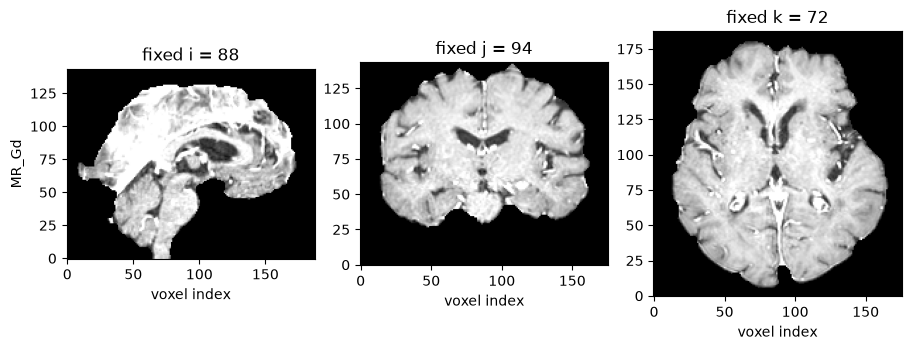

In [4]:
orthogonal_centers(highres, "MR_Gd", vmax)


In [ ]:
show_niivue([path_high], vmax=vmax)


## Tilted low-resolution slab

The slab keeps the in-plane field of view of `MR_Gd`, so the brain is not cropped to a 9 cm window. The voxels are coarser:

- 2.5 × 2.5 mm in plane
- 7.5 mm slice thickness
- 3 slices

It is tilted 25° about the source i axis, and its center sits on the center of `MR_Gd`. The in-plane size comes from the corners of `MR_Gd`, measured in the slab's plane, so a tilted cut still covers the head.


In [5]:
low_spacing = np.array([2.5, 2.5, 7.5])
n_slices = 3

center_index = (np.array(highres.shape[:3]) - 1) / 2.0
center_world = apply_affine(highres_affine, center_index)
tilt = directions_of(highres_affine) @ rotation_about_x(25)

ends = np.array(highres.shape[:3]) - 1.0
corner_list = [[i, j, k] for i in (0.0, ends[0]) for j in (0.0, ends[1]) for k in (0.0, ends[2])]
corners = apply_affine(highres_affine, np.array(corner_list))
in_plane = (corners - center_world) @ tilt
span_i = in_plane[:, 0].max() - in_plane[:, 0].min()
span_j = in_plane[:, 1].max() - in_plane[:, 1].min()
n_i = int(np.ceil(span_i / low_spacing[0])) + 1
n_j = int(np.ceil(span_j / low_spacing[1])) + 1
lowres_shape = (n_i, n_j, n_slices)
lowres_affine = grid_affine(lowres_shape, low_spacing, tilt, center_world)

print("lowres shape", lowres_shape)
print("in-plane span mm", np.round([span_i, span_j], 1), "slice thickness mm", low_spacing[2])
print("spacing from affine", np.round(np.linalg.norm(lowres_affine[:3, :3], axis=0), 3))


lowres shape (70, 92, 3)
in-plane span mm [170.9 226.1] slice thickness mm 7.5
spacing from affine [2.5 2.5 7.5]


## Resample high resolution onto the slab

For every voxel of the slab: index to millimetres with the slab affine, millimetres back to an index in `MR_Gd`, then linear interpolation. The result is `MR_Gd_tilt_lowres.nii.gz`.


In [6]:
lowres = resample_to_grid(highres, highres_affine, lowres_shape, lowres_affine)
path_low = save(lowres, lowres_affine, "MR_Gd_tilt_lowres.nii.gz")
print(path_low.name, lowres.shape, "min", float(lowres.min()), "max", float(lowres.max()))


MR_Gd_tilt_lowres.nii.gz (70, 92, 3) min 0.0 max 1440.3424072265625


The three slab slices are the whole low-resolution volume. In the index pictures the high-resolution scan is a full brain and the slab is three small squares. In NiiVue the coordinates button starts on world millimetres, so the green slab lies across the middle of the gray brain, tilted. Switch that button to voxel indices and the two grids no longer share a position, because 70×92×3 is not 176×188×144. The view button flips radiologic and neurologic display. The letters on the slice edges stay R, L, A, P, S, and I.


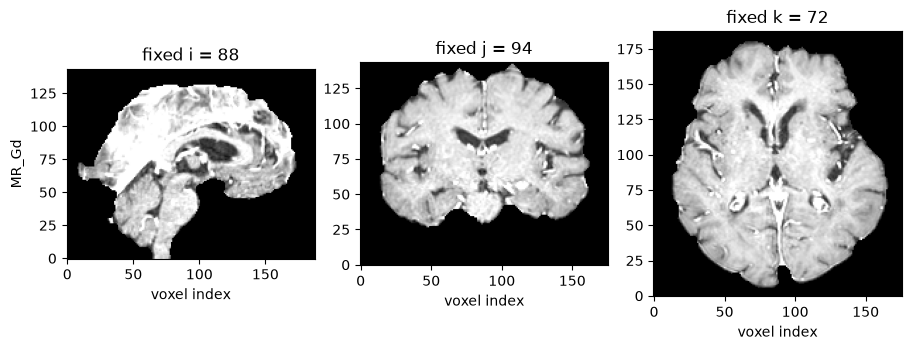

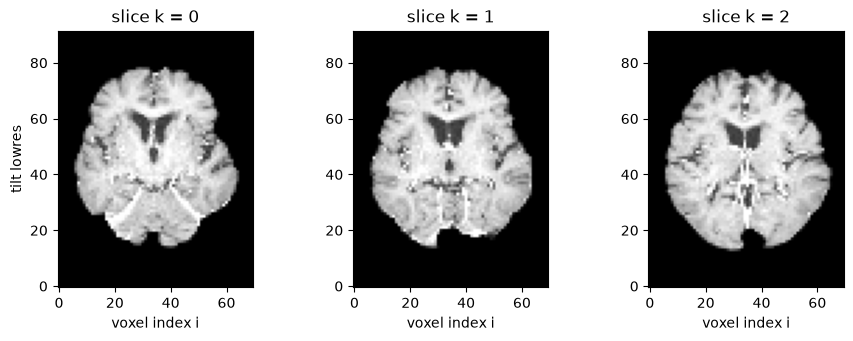

In [7]:
orthogonal_centers(highres, "MR_Gd", vmax)
slab_slices(lowres, "tilt lowres", vmax)


In [ ]:
show_niivue([path_high], vmax=vmax)


In [ ]:
show_niivue([path_low], vmax=vmax)


In [ ]:
show_niivue(
    [path_high, path_low],
    colormaps=["gray", "green"],
    opacities=[1.0, 0.55],
    vmax=vmax,
)


## Resample the high-resolution volume onto the slab again

The index pictures above do not line up. `MR_Gd` is 176×188×144 and the slab is 54×54×3, and their voxel axes point different ways. Matplotlib only compares arrays. It does not read the affine.

Resample `MR_Gd` onto the slab grid again. Both arrays are then the same shape, and the three slices match.


In [8]:
high_on_low = resample_to_grid(highres, highres_affine, lowres.shape, lowres_affine)
path_high_on_low = save(high_on_low, lowres_affine, "MR_Gd_highres_on_lowres.nii.gz")
print("max abs diff", float(np.max(np.abs(high_on_low - lowres))))


max abs diff 0.0


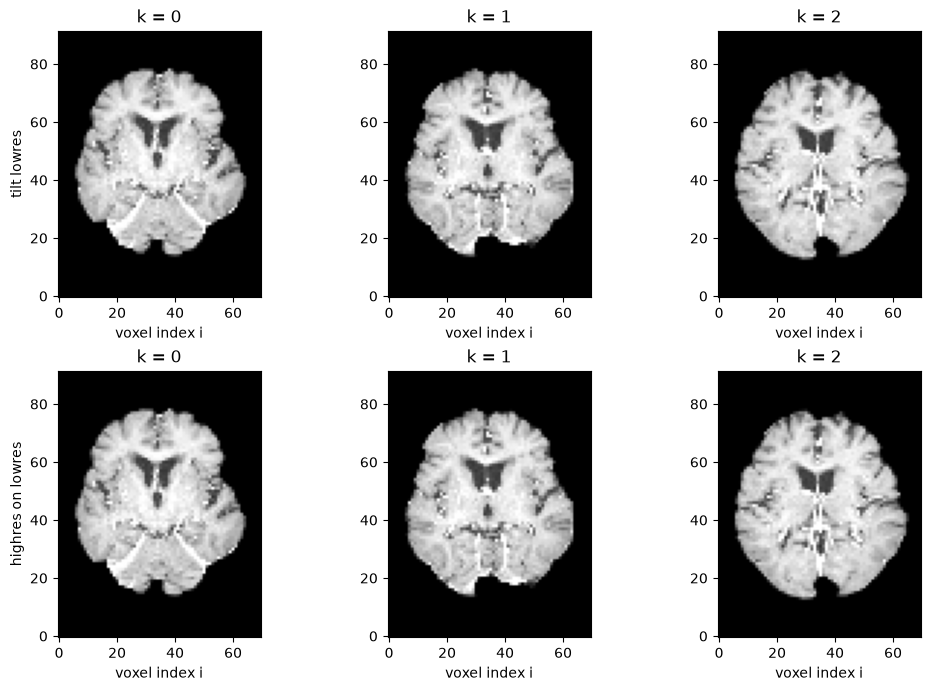

In [9]:
compare_slices(
    [("tilt lowres", lowres), ("highres on lowres", high_on_low)],
    ks=[0, 1, 2],
    vmax=vmax,
)


In [ ]:
show_niivue(
    [path_low, path_high_on_low],
    colormaps=["gray", "green"],
    opacities=[1.0, 0.45],
    vmax=vmax,
)


## Footprint average versus nibabel

Nibabel's `resample_from_to` (and the center-sample function above) reads one interpolated value at the center of each low-resolution voxel. A 7.5 mm slice does not do that. It averages the high-resolution signal over the whole voxel: 2.5 × 2.5 mm in plane and 7.5 mm through the slice.

The footprint resample places several samples inside each slab voxel and averages them. The slices are the same grid, so matplotlib can compare them. They do not match. The difference is the in-slice average.


In [10]:
from nibabel.processing import resample_from_to

high_nii = nib.Nifti1Image(highres, highres_affine)
nib_low = np.asanyarray(
    resample_from_to(high_nii, (lowres_shape, lowres_affine), order=1).dataobj,
    dtype=np.float32,
)
print("center sample vs nibabel, max abs", float(np.max(np.abs(nib_low - lowres))))

# One sample per source voxel inside the low-resolution voxel, at least 3 per edge.
samples = np.maximum(3, np.round(low_spacing / high_spacing).astype(int))
foot = resample_footprint(highres, highres_affine, lowres_shape, lowres_affine, samples)
path_foot = save(foot, lowres_affine, "MR_Gd_tilt_lowres_footprint.nii.gz")
path_nib = save(nib_low, lowres_affine, "MR_Gd_tilt_lowres_nibabel.nii.gz")
print("samples inside each voxel", tuple(int(n) for n in samples))
print("footprint vs nibabel, mean abs", float(np.mean(np.abs(foot - nib_low))))


center sample vs nibabel, max abs 0.0
samples inside each voxel (3, 3, 7)
footprint vs nibabel, mean abs 17.30442237854004


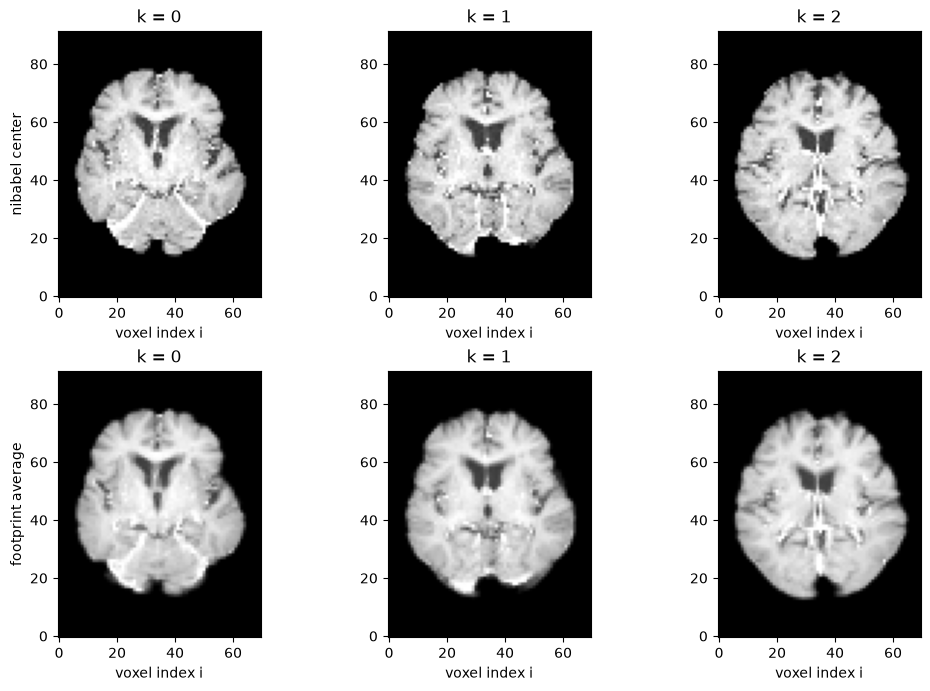

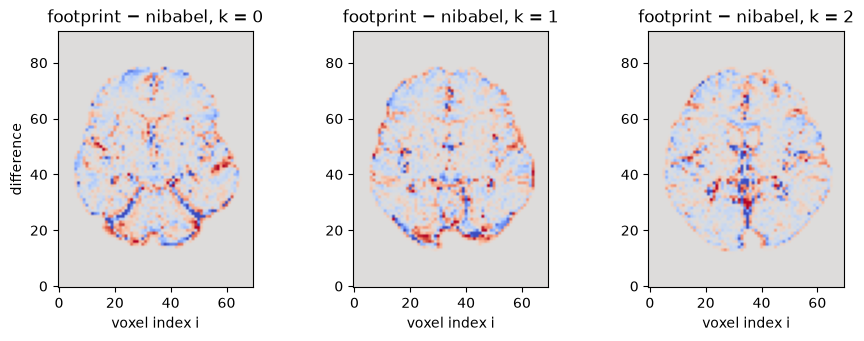

In [11]:
compare_slices(
    [("nibabel center", nib_low), ("footprint average", foot)],
    ks=[0, 1, 2],
    vmax=vmax,
)

diff = foot - nib_low
dmax = float(np.percentile(np.abs(diff), 99))
fig, axes = plt.subplots(1, 3, figsize=(9, 3.3), layout="constrained")
for k, ax in enumerate(axes):
    ax.imshow(diff[:, :, k].T, cmap="coolwarm", origin="lower", vmin=-dmax, vmax=dmax)
    ax.set_title(f"footprint − nibabel, k = {k}")
    ax.set_xlabel("voxel index i")
axes[0].set_ylabel("difference")
plt.show()


In [ ]:
show_niivue(
    [path_nib, path_foot],
    colormaps=["gray", "green"],
    opacities=[1.0, 0.5],
    vmax=vmax,
)


## Resample the slab back onto the high-resolution grid

Same function, grids swapped. The output has the shape of `MR_Gd` again. Only the voxels that land inside the 9 mm slab get intensities. Everywhere else stays 0, because the slab has no data there.


In [12]:
back = resample_to_grid(lowres, lowres_affine, highres.shape, highres_affine)
path_back = save(back, highres_affine, "MR_Gd_lowres_on_highres.nii.gz")
print(path_back.name, back.shape)


MR_Gd_lowres_on_highres.nii.gz (176, 188, 144)


Center slice of the high-resolution volume, and the same index after the round trip. The band is where the tilted slab cuts this plane. The rest of the slice is empty.


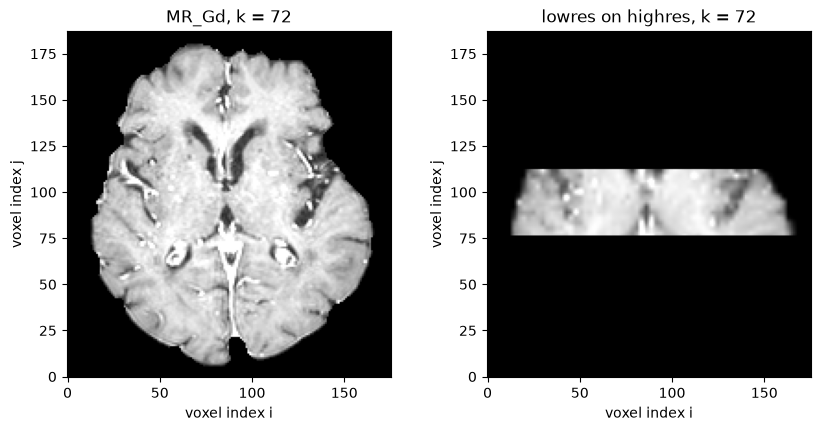

In [13]:
center_k(
    [("MR_Gd", highres), ("lowres on highres", back)],
    vmax,
)


In [ ]:
show_niivue(
    [path_high, path_back],
    colormaps=["gray", "red"],
    opacities=[0.35, 1.0],
    vmax=vmax,
)


## Both volumes at 0.5 mm, in the slab frame

Same orientation and the same field of view as the slab, but the voxels are 0.5 mm isotropic. Resample `MR_Gd` and the low-resolution slab onto that grid. The three planes that used to be the slab slices now have the same voxel indices in both arrays, so matplotlib lines them up. The row from `MR_Gd` is sharper. The row from the 2.5 × 2.5 × 7.5 mm slab is the same cut, smoothed by the coarse voxels. That resample uses `mode="nearest"` so the last of the three slices is kept, instead of being mixed with zeros.


In [14]:
iso = 0.5
span = (np.asarray(lowres_shape) - 1) * low_spacing
iso_shape = tuple(int(n) for n in (np.round(span / iso).astype(int) + 1))
iso_affine = grid_affine(iso_shape, (iso, iso, iso), tilt, center_world)

high_on_iso = resample_to_grid(highres, highres_affine, iso_shape, iso_affine)
low_on_iso = resample_to_grid(lowres, lowres_affine, iso_shape, iso_affine, mode="nearest")
path_iso_high = save(high_on_iso, iso_affine, "MR_Gd_slab_0.5mm.nii.gz")
path_iso_low = save(low_on_iso, iso_affine, "MR_Gd_tilt_lowres_0.5mm.nii.gz")

low_center_k = (lowres_shape[2] - 1) / 2.0
iso_center_k = (iso_shape[2] - 1) / 2.0
ks_iso = [
    int(round(iso_center_k + (k - low_center_k) * (low_spacing[2] / iso)))
    for k in range(lowres_shape[2])
]
print("0.5 mm shape", iso_shape, "span mm", np.round(span, 1))
print("slab slices land on k", ks_iso)


0.5 mm shape (346, 456, 31) span mm [172.5 227.5  15. ]
slab slices land on k [0, 15, 30]


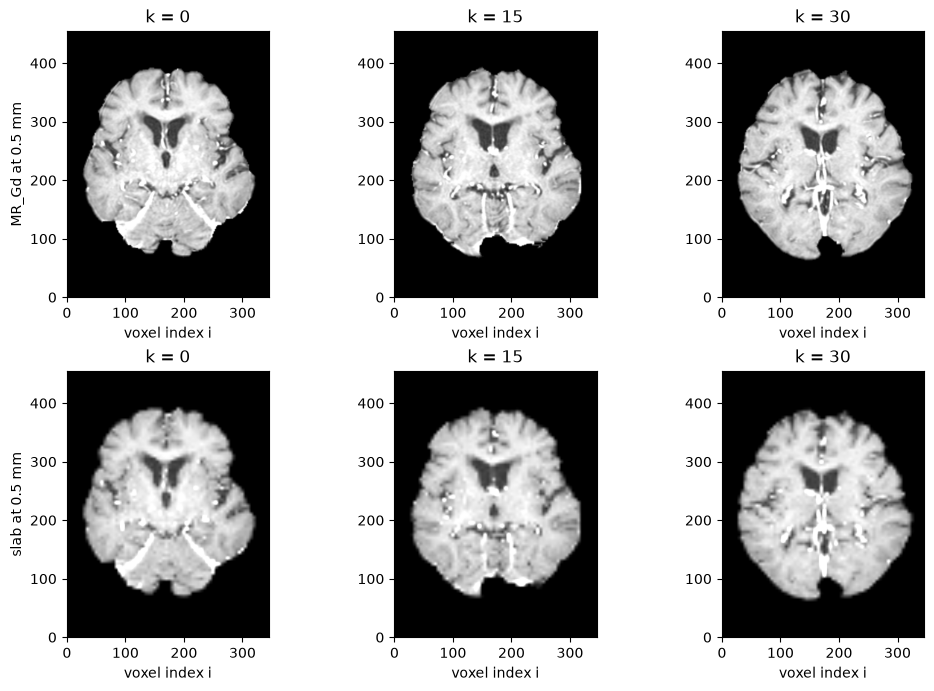

In [15]:
compare_slices(
    [("MR_Gd at 0.5 mm", high_on_iso), ("slab at 0.5 mm", low_on_iso)],
    ks=ks_iso,
    vmax=vmax,
)


In [ ]:
show_niivue(
    [path_iso_high, path_iso_low],
    colormaps=["gray", "green"],
    opacities=[1.0, 0.5],
    vmax=vmax,
)
